# Sliced Wasserstein Gradient Descent to a Target

The sliced Wasserstein distance between empirical measures is
$$
\mathrm{SW}^2(\mu,\nu)=\int_{\mathbb{S}^{d-1}} W_2^2(\theta_\#\mu,\theta_\#\nu)\,d\theta.
$$
We optimize source particles by gradient descent to match a target distribution, and ensure good final alignment.


## SW descent with random projection directions


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)

OUT = Path("python/sliced-wasserstein"); OUT.mkdir(parents=True, exist_ok=True)
n = 420
Xt = np.vstack([
    rng.normal(loc=[-1.1, 0.8], scale=[0.25, 0.18], size=(n//3, 2)),
    rng.normal(loc=[0.9, 0.6], scale=[0.22, 0.2], size=(n//3, 2)),
    rng.normal(loc=[0.1, -0.9], scale=[0.28, 0.22], size=(n - 2*(n//3), 2)),
])
Xs = rng.normal(0, 0.9, size=(n, 2))
traj = [Xs.copy()]

def sw_grad(X, Y, n_dir=70):
    G = np.zeros_like(X)
    thetas = rng.uniform(0, np.pi, size=n_dir)
    for a in thetas:
        th = np.array([np.cos(a), np.sin(a)])
        px = X @ th
        py = Y @ th
        ix = np.argsort(px)
        iy = np.argsort(py)
        diff = px[ix] - py[iy]
        g = np.zeros(len(X))
        g[ix] = diff
        G += g[:, None] * th[None, :]
    return (2.0 / n_dir) * G

lr = 0.18
for _ in range(120):
    grad = sw_grad(Xs, Xt, n_dir=90)
    Xs = Xs - lr * grad
    traj.append(Xs.copy())


## Source-to-target matching


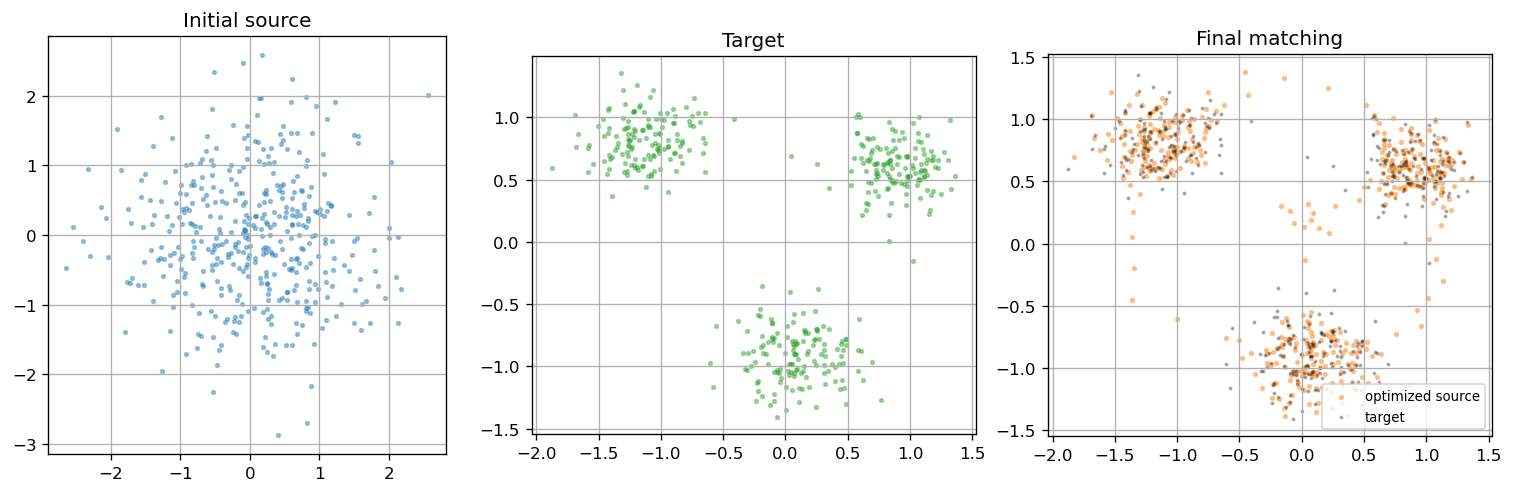

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0), constrained_layout=True)
axes[0].scatter(traj[0][:,0], traj[0][:,1], s=5, alpha=0.4)
axes[0].set_title("Initial source")
axes[1].scatter(Xt[:,0], Xt[:,1], s=5, alpha=0.4, color="tab:green")
axes[1].set_title("Target")
axes[2].scatter(traj[-1][:,0], traj[-1][:,1], s=5, alpha=0.4, color="tab:orange", label="optimized source")
axes[2].scatter(Xt[:,0], Xt[:,1], s=2, alpha=0.25, color="k", label="target")
axes[2].legend(loc="lower right", fontsize=8)
axes[2].set_title("Final matching")
for ax in axes:
    ax.set_aspect("equal")
fig.savefig(OUT / "snippet.png", bbox_inches="tight")
plt.show()
